In [1]:
import torch

from pprint import pprint
from decoder_patching import *
from utils import REPO_ROOT, preprocess_mask_predict_data

In [2]:
iter_nums = 10

prep_result = preprocess_mask_predict_data(
    input_dir=REPO_ROOT / "input",
    output_dir=REPO_ROOT / "output",
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    run_name="en_de_demo",
    workers=10,
)

In [3]:
state = torch.load("./checkpoints/maskPredict_en_de/checkpoint_best.pt", map_location="cpu", weights_only=False)
model_args = state["args"]

for k in [
    "arch",
    "encoder_layers",
    "encoder_embed_dim",
    "encoder_ffn_embed_dim",
    "encoder_attention_heads",
    "decoder_layers",
    "decoder_embed_dim",
    "decoder_ffn_embed_dim",
    "decoder_attention_heads",
]:
    if hasattr(model_args, k):
        print(k, "=", getattr(model_args, k))


arch = bert_transformer_seq2seq
encoder_layers = 6
encoder_embed_dim = 512
encoder_ffn_embed_dim = 2048
encoder_attention_heads = 8
decoder_layers = 6
decoder_embed_dim = 512
decoder_ffn_embed_dim = 2048
decoder_attention_heads = 8


In [4]:
context = load_mask_predict_context(
    data_bin_dir=prep_result["data_bin_dir"],
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    decoding_iterations=iter_nums,
    length_beam=1,
    max_sentences=20,
    use_cpu=True,
)

In [5]:
encoder_example = get_encoder_output(
    "China is a large country in Asia , and the capital of the country is Beijing .",
    context,
)

print("sentence:", encoder_example["sentence"])
print("src_tokens shape:", tuple(encoder_example["src_tokens"].shape))
print("src_lengths:", encoder_example["src_lengths"].tolist())
print("predicted target length:", int(encoder_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))

sentence: China is a large country in Asia , and the capital of the country is Beijing .
src_tokens shape: (1, 18)
src_lengths: [18]
predicted target length: 16


## Test on patching

In [6]:
source_sentence = "The bank was steep beside the stream ."
target_sentence = "The bank was open beside the market ."
# source_sentence = "The bank was open beside the market ."
# target_sentence = "The bank is open beside the market ."

source_example = get_encoder_output(source_sentence, context)
target_example = get_encoder_output(target_sentence, context)

In [7]:
print("patch source sentence:", source_example["sentence"])
print("patch target sentence:", target_example["sentence"])
src_dict = context["task"].source_dictionary
source_token_ids = source_example["src_tokens"][0].tolist()
target_token_ids = target_example["src_tokens"][0].tolist()
source_token_text = [src_dict[token_id] for token_id in source_token_ids]
target_token_text = [src_dict[token_id] for token_id in target_token_ids]
print("patch source token ids:", [source_token_ids])
print("patch source token texts:", source_token_text)
print("patch source token pairs:", list(zip(source_token_ids, source_token_text)))
print("patch target token ids:", [target_token_ids])
print("patch target token texts:", target_token_text)
print("patch target token pairs:", list(zip(target_token_ids, target_token_text)))
print("patch source predicted target length:", int(source_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))
print("patch target predicted target length:", int(target_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))

patch source sentence: The bank was steep beside the stream .
patch target sentence: The bank was open beside the market .
patch source token ids: [[30, 2711, 66, 23863, 20645, 7, 9925, 6, 2]]
patch source token texts: ['The', 'bank', 'was', 'steep', 'beside', 'the', 'stream', '.', '</s>']
patch source token pairs: [(30, 'The'), (2711, 'bank'), (66, 'was'), (23863, 'steep'), (20645, 'beside'), (7, 'the'), (9925, 'stream'), (6, '.'), (2, '</s>')]
patch target token ids: [[30, 2711, 66, 861, 20645, 7, 375, 6, 2]]
patch target token texts: ['The', 'bank', 'was', 'open', 'beside', 'the', 'market', '.', '</s>']
patch target token pairs: [(30, 'The'), (2711, 'bank'), (66, 'was'), (861, 'open'), (20645, 'beside'), (7, 'the'), (375, 'market'), (6, '.'), (2, '</s>')]
patch source predicted target length: 9
patch target predicted target length: 9


In [8]:
layer_index = 4

source_predicted_length = int(source_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item())
target_predicted_length = int(target_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item())

print("decoder layer index:", layer_index)
print("patch mode:", "full_layer")
print("source predicted target length:", source_predicted_length)
print("target predicted target length:", target_predicted_length)
print("full layer patch requires matching lengths:", source_predicted_length == target_predicted_length)

decoder layer index: 4
patch mode: full_layer
source predicted target length: 9
target predicted target length: 9
full layer patch requires matching lengths: True


In [9]:
decoded_original_target = decode_from_encoder_output(
    target_example["encoder_out"],
    context=context,
    decoding_iterations=iter_nums,
)

decoder_patch_result = decoder_patching(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    layer_index=layer_index,
    decoding_iterations=iter_nums,
)

In [10]:
print("source sentence:", source_sentence)
print("target sentence:", target_sentence)
print("decoded from original target encoder:", decoded_original_target["decoded_text"])
print("decoded from decoder-patched target:", decoder_patch_result["decoded_text"])
print()
print("patched decoder iteration trace:")
for step in decoder_patch_result["iteration_trace"]:
    print(f"iter {step['iteration']:02d}: {step['text']}")
    print("  selected mask tokens:", step["selected_mask_tokens"])
    print("  selected mask probs:", step["selected_mask_probs"])
    print("  token mask probs:", step["token_mask_probs"])

source sentence: The bank was steep beside the stream .
target sentence: The bank was open beside the market .
decoded from original target encoder: Die Bank war neben dem Markt offen .
decoded from decoder-patched target: Die Bank war offen neben dem Markt .

patched decoder iteration trace:
iter 00: Die Bank war neben neben dem offen .
  selected mask tokens: []
  selected mask probs: []
  token mask probs: [0.410974, 0.045048, 0.186969, 0.484206, 0.246763, 0.489795, 0.585527, 0.101929, 0.088795]
iter 01: Die Bank war offen neben dem Markt .
  selected mask tokens: ['offen', 'dem', 'neben', 'Die', 'neben', 'war', '.', '</s>']
  selected mask probs: [0.585527, 0.489795, 0.484206, 0.410974, 0.246763, 0.186969, 0.101929, 0.088795]
  token mask probs: [0.34076, 0.045048, 0.093009, 0.73115, 0.081513, 0.152078, 0.391344, 0.099598, 0.091254]
iter 02: Die Bank war offen neben dem Markt .
  selected mask tokens: ['offen', 'Markt', 'Die', 'dem', '.', 'war', '</s>']
  selected mask probs: [0.73

In [11]:
print("decoder patch activation trace:")
for step in decoder_patch_result["patch_trace"]:
    print(f"iter {step['iteration']:02d}:")
    print("  activation shape:", step["activation_shape"])
    print("  source text:", step["source_text"])
    print("  patched text:", step["patched_text"])


decoder patch activation trace:
iter 00:
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben Fluss Fluss .
  patched text: Die Bank war neben neben dem offen .
iter 01:
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war offen neben dem Markt .
iter 02:
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war offen neben dem Markt .
iter 03:
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war offen neben dem Markt .
iter 04:
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war offen neben dem Markt .
iter 05:
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war offen neben dem Markt .
iter 06:
  activation shape: [9, 1, 512]
  source text: Die Ufer war steil neben dem Fluss

In [12]:
final_predicted_sentence = decoder_patch_result["decoded_text"]
print("final predicted sentence:", final_predicted_sentence)

final predicted sentence: Die Bank war offen neben dem Markt .


In [13]:
pprint(decoder_patch_result["patch_trace"][-1])

{'activation_shape': [9, 1, 512],
 'iteration': 9,
 'patch_mode': 'full_layer',
 'patched_text': 'Die Bank war offen neben dem Markt .',
 'source_activation_norm': 35.360016,
 'source_text': 'Das Ufer war steil neben dem Fluss .',
 'target_activation_norm_after_patch': 35.360016,
 'target_activation_norm_before_patch': 34.781525}


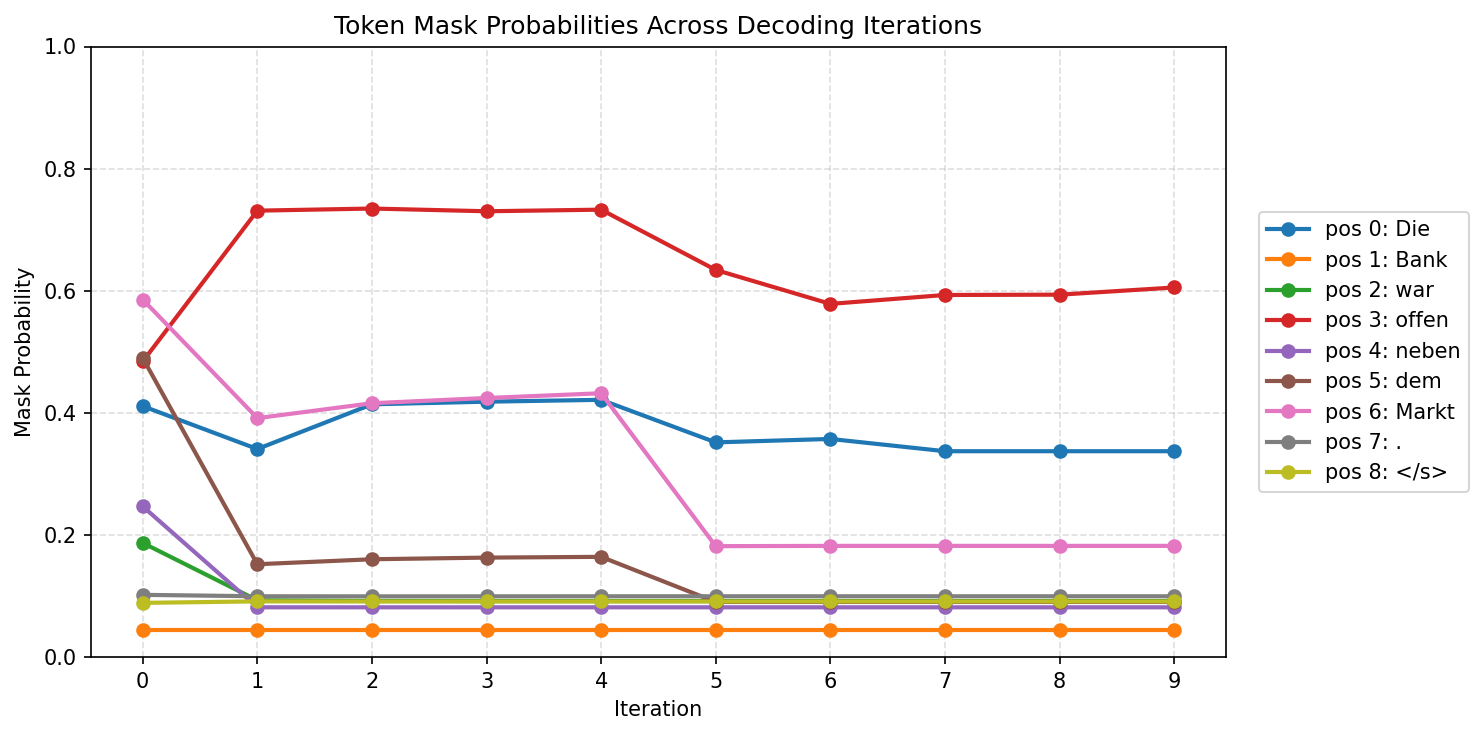

In [14]:
plot_token_mask_probs(decoder_patch_result)

In [15]:
print("final iteration mask probabilities:", decoder_patch_result["iteration_trace"][-1]["token_mask_probs"])


final iteration mask probabilities: [0.337167, 0.045048, 0.091764, 0.605313, 0.081513, 0.090267, 0.182126, 0.099584, 0.091049]


In [48]:
patched_token_idx = 1
tracked_token_id = decoded_original_target["token_ids"][patched_token_idx]
tracked_token_text = context["task"].target_dictionary[tracked_token_id]

print("tracked token position:", patched_token_idx)
print("tracked token in original target decode:", tracked_token_text)
print("original target decode:", decoded_original_target["decoded_text"])


tracked token position: 1
tracked token in original target decode: Bank
original target decode: Die Bank war neben dem Markt offen .


In [49]:
layer_sweep_result = decoder_layer_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=patched_token_idx,
    decoding_iterations=iter_nums,
)


In [50]:
print("layerwise decoder patching results:")
for layer_result in layer_sweep_result["layer_results"]:
    print(f"layer {layer_result['layer_index']}: {layer_result['decoded_text']}")
    print("  tracked token texts by iteration:", layer_result["tracked_token_texts_by_iteration"])
    print("  tracked token mask probs:", layer_result["tracked_token_mask_probs"])


layerwise decoder patching results:
layer 0: Die Bank war offen neben dem Markt .
  tracked token texts by iteration: ['Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank']
  tracked token mask probs: [0.067618, 0.067618, 0.067618, 0.067618, 0.067618, 0.067618, 0.067618, 0.067618, 0.067618, 0.067618]
layer 1: Die Bank war offen neben dem Markt .
  tracked token texts by iteration: ['Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank']
  tracked token mask probs: [0.051259, 0.051259, 0.051259, 0.051259, 0.051259, 0.051259, 0.051259, 0.051259, 0.051259, 0.051259]
layer 2: Die Bank war offen neben dem Markt .
  tracked token texts by iteration: ['Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank', 'Bank']
  tracked token mask probs: [0.042573, 0.042573, 0.042573, 0.042573, 0.042573, 0.042573, 0.042573, 0.042573, 0.042573, 0.042573]
layer 3: Die Bank war offen neben dem Markt .
  tracked token texts by iteration: ['Bank

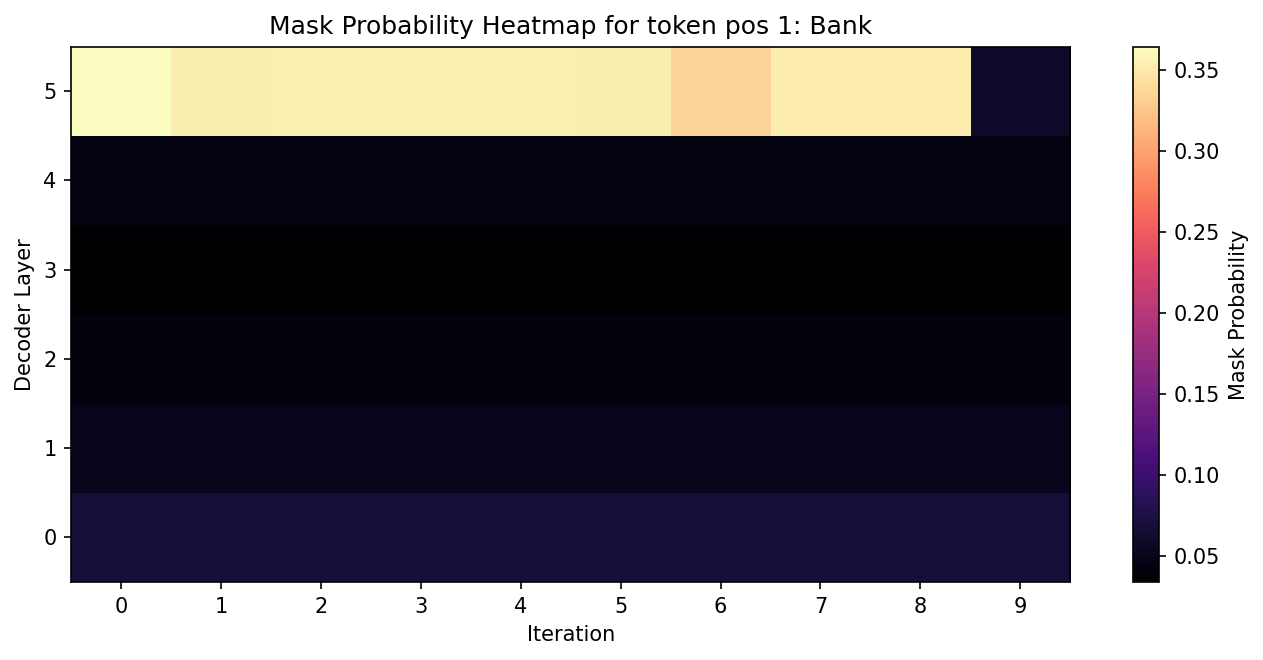

In [51]:
plot_layerwise_token_mask_heatmap(layer_sweep_result)


In [20]:
self_attn_layer_index = 5
self_attn_token_position = 2
self_attn_token_id = decoded_original_target["token_ids"][self_attn_token_position]
self_attn_token_text = context["task"].target_dictionary[self_attn_token_id]

print("self-attn layer index:", self_attn_layer_index)
print("self-attn token position:", self_attn_token_position)
print("tracked target token in original decode:", self_attn_token_text)


self-attn layer index: 5
self-attn token position: 2
tracked target token in original decode: war


In [21]:
decoder_self_attn_patch_result = decoder_self_attn_token_patching(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    layer_index=self_attn_layer_index,
    token_position=self_attn_token_position,
    decoding_iterations=iter_nums,
)


In [22]:
print("decoded from original target encoder:", decoded_original_target["decoded_text"])
print("decoded from decoder self-attn patched target:", decoder_self_attn_patch_result["decoded_text"])
print()
print("decoder self-attn patch trace:")
for step in decoder_self_attn_patch_result["patch_trace"]:
    print(f"iter {step['iteration']:02d}:")
    print("  patch mode:", step["patch_mode"])
    print("  module:", step["module_name"])
    print("  token position:", step["token_position"])
    print("  source text:", step["source_text"])
    print("  patched text:", step["patched_text"])


decoded from original target encoder: Die Bank war neben dem Markt offen .
decoded from decoder self-attn patched target: Die Bank war neben dem Markt offen .

decoder self-attn patch trace:
iter 00:
  patch mode: self_attn_source_to_target
  module: decoder.layers.5.self_attn
  token position: 2
  source text: Die Ufer war steil neben Fluss Fluss .
  patched text: Die Bank war neben dem Markt geöffnet .
iter 01:
  patch mode: self_attn_source_to_target
  module: decoder.layers.5.self_attn
  token position: 2
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war neben dem Markt offen .
iter 02:
  patch mode: self_attn_source_to_target
  module: decoder.layers.5.self_attn
  token position: 2
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war neben dem Markt geöffnet .
iter 03:
  patch mode: self_attn_source_to_target
  module: decoder.layers.5.self_attn
  token position: 2
  source text: Die Ufer war steil neben dem Fluss .
  patc

In [23]:
final_self_attn_predicted_sentence = decoder_self_attn_patch_result["decoded_text"]
print("final self-attn patched target sentence:", final_self_attn_predicted_sentence)


final self-attn patched target sentence: Die Bank war neben dem Markt offen .


In [24]:
bank_token_position = patched_token_idx
bank_token_id = decoded_original_target["token_ids"][bank_token_position]
bank_token_text = context["task"].target_dictionary[bank_token_id]
self_attn_iters = list(range(iter_nums))

print("bank token position:", bank_token_position)
print("bank token in original target decode:", bank_token_text)
print("self-attn sweep patch iterations:", self_attn_iters)


bank token position: 2
bank token in original target decode: war
self-attn sweep patch iterations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [25]:
self_attn_bank_sweep_result = decoder_self_attn_layer_iteration_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=bank_token_position,
    patch_token_position=bank_token_position,
    decoding_iterations=iter_nums,
    patch_iterations=self_attn_iters,
)


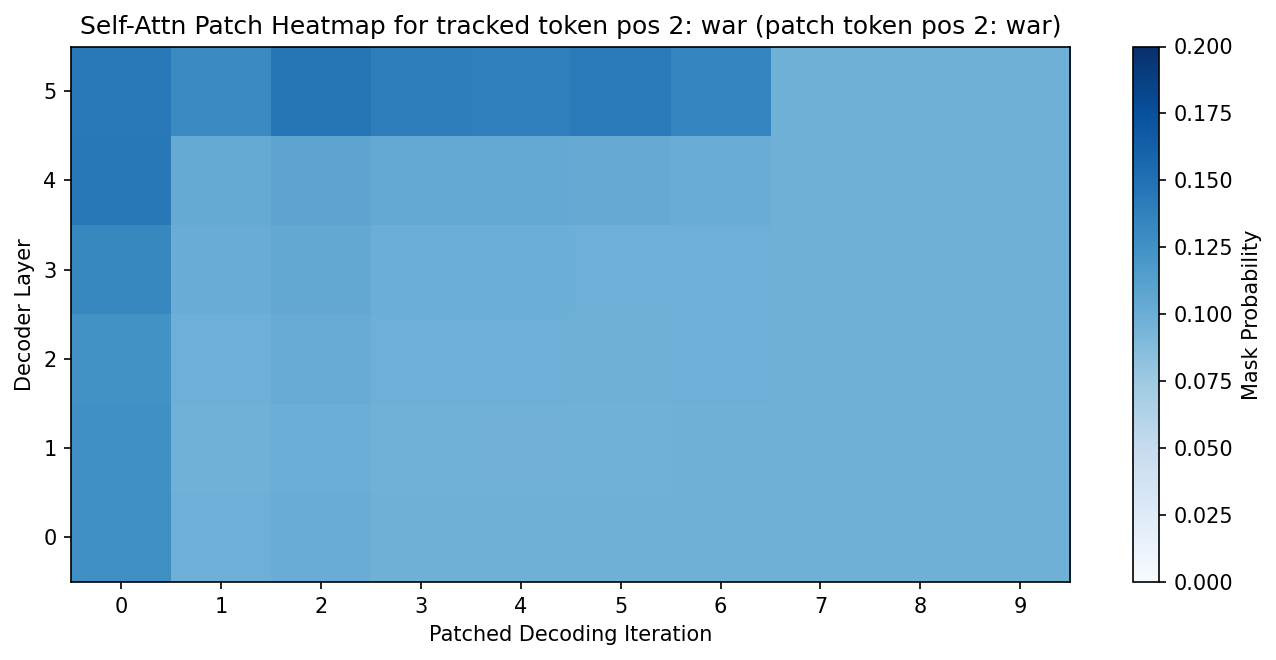

In [26]:
plot_self_attn_layer_iteration_heatmap(self_attn_bank_sweep_result,cmap="Blues")


In [27]:
cross_attn_layer_index = 5
cross_attn_token_position = bank_token_position
cross_attn_token_id = decoded_original_target["token_ids"][cross_attn_token_position]
cross_attn_token_text = context["task"].target_dictionary[cross_attn_token_id]

print("cross-attn layer index:", cross_attn_layer_index)
print("cross-attn token position:", cross_attn_token_position)
print("tracked target token in original decode:", cross_attn_token_text)


cross-attn layer index: 5
cross-attn token position: 2
tracked target token in original decode: war


In [28]:
decoder_cross_attn_patch_result = decoder_cross_attn_token_patching(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    layer_index=cross_attn_layer_index,
    token_position=cross_attn_token_position,
    decoding_iterations=iter_nums,
)


In [29]:
print("decoded from original target encoder:", decoded_original_target["decoded_text"])
print("decoded from decoder cross-attn patched target:", decoder_cross_attn_patch_result["decoded_text"])
print()
print("decoder cross-attn patch trace:")
for step in decoder_cross_attn_patch_result["patch_trace"]:
    print(f"iter {step['iteration']:02d}:")
    print("  patch mode:", step["patch_mode"])
    print("  module:", step["module_name"])
    print("  token position:", step["token_position"])
    print("  source text:", step["source_text"])
    print("  patched text:", step["patched_text"])
    print("  activation shape:", step["activation_shape"])
    print("  source activation norm:", step["source_activation_norm"])
    print("  target activation norm before patch:", step["target_activation_norm_before_patch"])
    print("  target activation norm after patch:", step["target_activation_norm_after_patch"])


decoded from original target encoder: Die Bank war neben dem Markt offen .
decoded from decoder cross-attn patched target: Die Bank war neben dem Markt offen .

decoder cross-attn patch trace:
iter 00:
  patch mode: cross_attn_source_to_target
  module: decoder.layers.5.encoder_attn
  token position: 2
  source text: Die Ufer war steil neben Fluss Fluss .
  patched text: Die Bank war neben dem Markt geöffnet .
  activation shape: [512]
  source activation norm: 5.835281
  target activation norm before patch: 4.956717
  target activation norm after patch: 5.835281
iter 01:
  patch mode: cross_attn_source_to_target
  module: decoder.layers.5.encoder_attn
  token position: 2
  source text: Die Ufer war steil neben dem Fluss .
  patched text: Die Bank war neben dem Markt offen .
  activation shape: [512]
  source activation norm: 5.077081
  target activation norm before patch: 4.88988
  target activation norm after patch: 5.077081
iter 02:
  patch mode: cross_attn_source_to_target
  module

In [30]:
final_cross_attn_predicted_sentence = decoder_cross_attn_patch_result["decoded_text"]
print("final cross-attn patched target sentence:", final_cross_attn_predicted_sentence)


final cross-attn patched target sentence: Die Bank war neben dem Markt offen .


In [31]:
cross_attn_iters = list(range(iter_nums))

print("cross-attn bank token position:", bank_token_position)
print("cross-attn bank token in original target decode:", bank_token_text)
print("cross-attn sweep patch iterations:", cross_attn_iters)


cross-attn bank token position: 2
cross-attn bank token in original target decode: war
cross-attn sweep patch iterations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [32]:
cross_attn_bank_sweep_result = decoder_cross_attn_layer_iteration_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=bank_token_position,
    patch_token_position=bank_token_position,
    decoding_iterations=iter_nums,
    patch_iterations=cross_attn_iters,
)


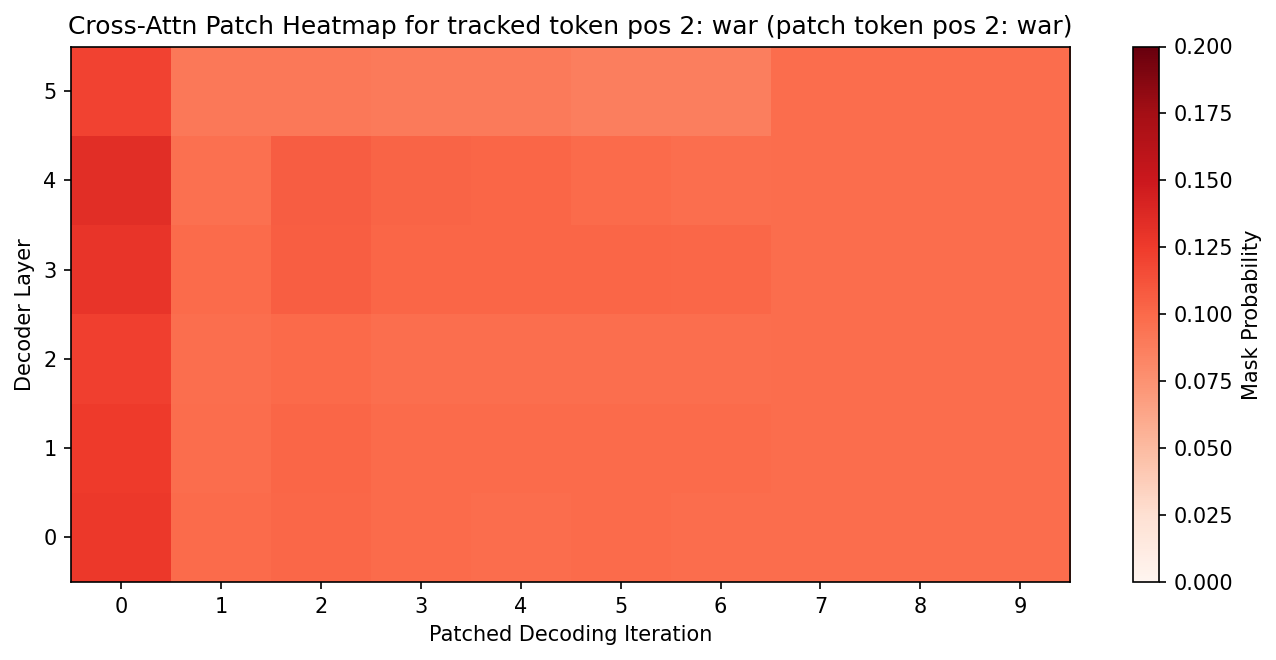

In [33]:
plot_cross_attn_layer_iteration_heatmap(cross_attn_bank_sweep_result, cmap="Reds")


## Test on full-layer patching

In [34]:
self_attn_full_iters = list(range(iter_nums))

print("self-attn full-layer bank token position:", bank_token_position)
print("self-attn full-layer bank token in original target decode:", bank_token_text)
print("self-attn full-layer sweep patch iterations:", self_attn_full_iters)


self-attn full-layer bank token position: 2
self-attn full-layer bank token in original target decode: war
self-attn full-layer sweep patch iterations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [35]:
self_attn_full_layer_bank_sweep_result = decoder_self_attn_full_layer_iteration_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=bank_token_position,
    decoding_iterations=iter_nums,
    patch_iterations=self_attn_full_iters,
)


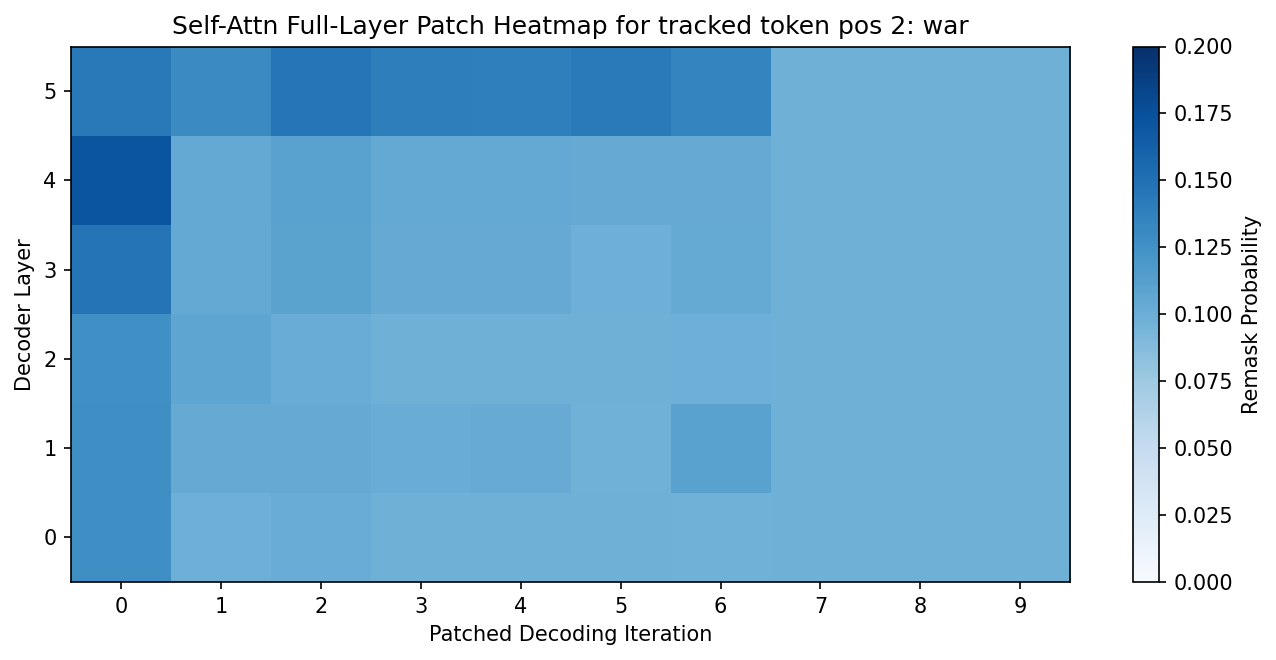

In [36]:
plot_self_attn_full_layer_iteration_heatmap(self_attn_full_layer_bank_sweep_result, cmap="Blues")


In [37]:
cross_attn_full_iters = list(range(iter_nums))

print("cross-attn full-layer bank token position:", bank_token_position)
print("cross-attn full-layer bank token in original target decode:", bank_token_text)
print("cross-attn full-layer sweep patch iterations:", cross_attn_full_iters)


cross-attn full-layer bank token position: 2
cross-attn full-layer bank token in original target decode: war
cross-attn full-layer sweep patch iterations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [38]:
cross_attn_full_layer_bank_sweep_result = decoder_cross_attn_full_layer_iteration_sweep(
    source_sentence=source_sentence,
    target_sentence=target_sentence,
    context=context,
    tracked_token_position=bank_token_position,
    decoding_iterations=iter_nums,
    patch_iterations=cross_attn_full_iters,
)


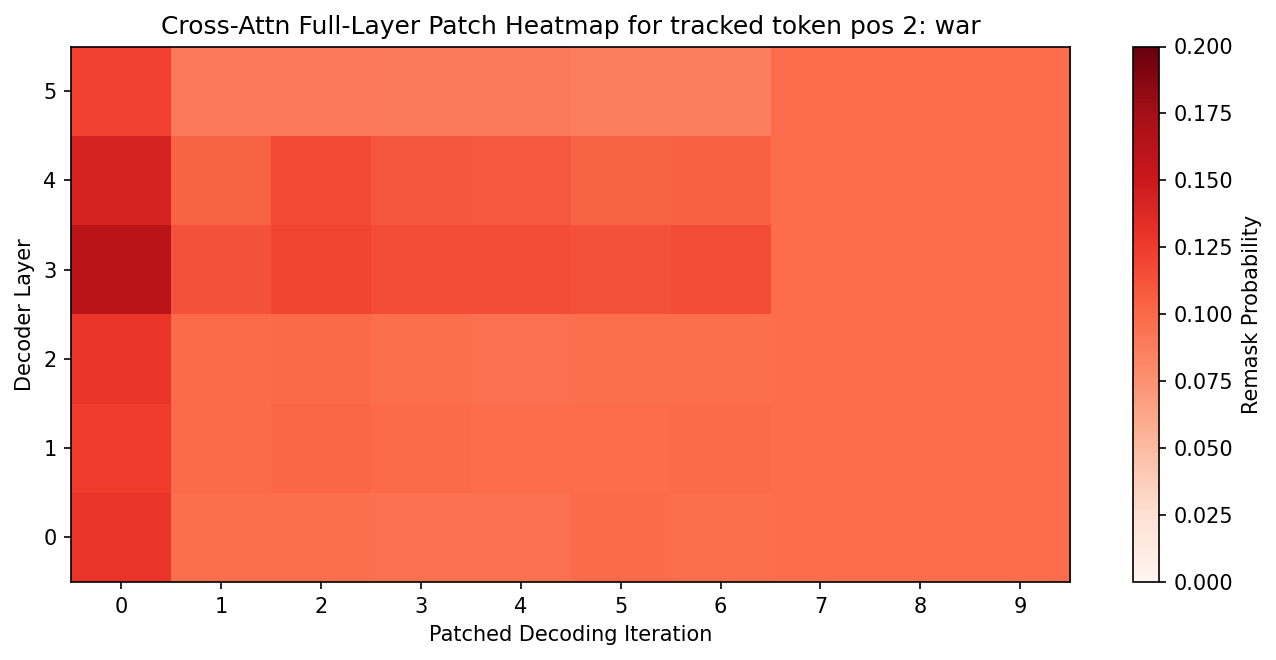

In [39]:
plot_cross_attn_full_layer_iteration_heatmap(cross_attn_full_layer_bank_sweep_result, cmap="Reds")


## Self-attn head zero ablation


In [40]:
self_attn_head_zero_layer_index = self_attn_layer_index

print("self-attn head zero layer index:", self_attn_head_zero_layer_index)
print("target sentence for head zero ablation:", target_sentence)


self-attn head zero layer index: 5
target sentence for head zero ablation: The bank was open beside the market .


In [41]:
self_attn_head_zero_sweep_result = decoder_self_attn_head_zero_ablation_sweep(
    target_sentence=target_sentence,
    context=context,
    layer_index=self_attn_head_zero_layer_index,
    decoding_iterations=iter_nums,
)


In [42]:
print("self-attn head zero ablation results:")
for head_result in self_attn_head_zero_sweep_result["head_results"]:
    print(
        f"head {head_result['head_index']}: overall avg mask prob = {head_result['overall_average_mask_prob']}"
    )
    print("  avg mask probs by iteration:", head_result["average_token_mask_probs_by_iteration"])
    print("  decoded text:", head_result["decoded_text"])


self-attn head zero ablation results:
head 0: overall avg mask prob = 0.135811
  avg mask probs by iteration: [0.139614, 0.133758, 0.135487, 0.136033, 0.136355, 0.136067, 0.135569, 0.135043, 0.135091, 0.135091]
  decoded text: Die Bank war neben dem Markt offen .
head 1: overall avg mask prob = 0.140245
  avg mask probs by iteration: [0.158328, 0.137333, 0.137863, 0.139185, 0.138596, 0.13904, 0.138354, 0.137829, 0.137962, 0.137962]
  decoded text: Die Bank war neben dem Markt offen .
head 2: overall avg mask prob = 0.133028
  avg mask probs by iteration: [0.152881, 0.131784, 0.132746, 0.130517, 0.130271, 0.130513, 0.130518, 0.13037, 0.130339, 0.130339]
  decoded text: Die Bank war neben dem Markt offen .
head 3: overall avg mask prob = 0.149318
  avg mask probs by iteration: [0.168213, 0.146322, 0.147391, 0.147403, 0.147291, 0.147196, 0.147547, 0.147159, 0.147329, 0.147329]
  decoded text: Die Bank war neben dem Markt offen .
head 4: overall avg mask prob = 0.130382
  avg mask probs by

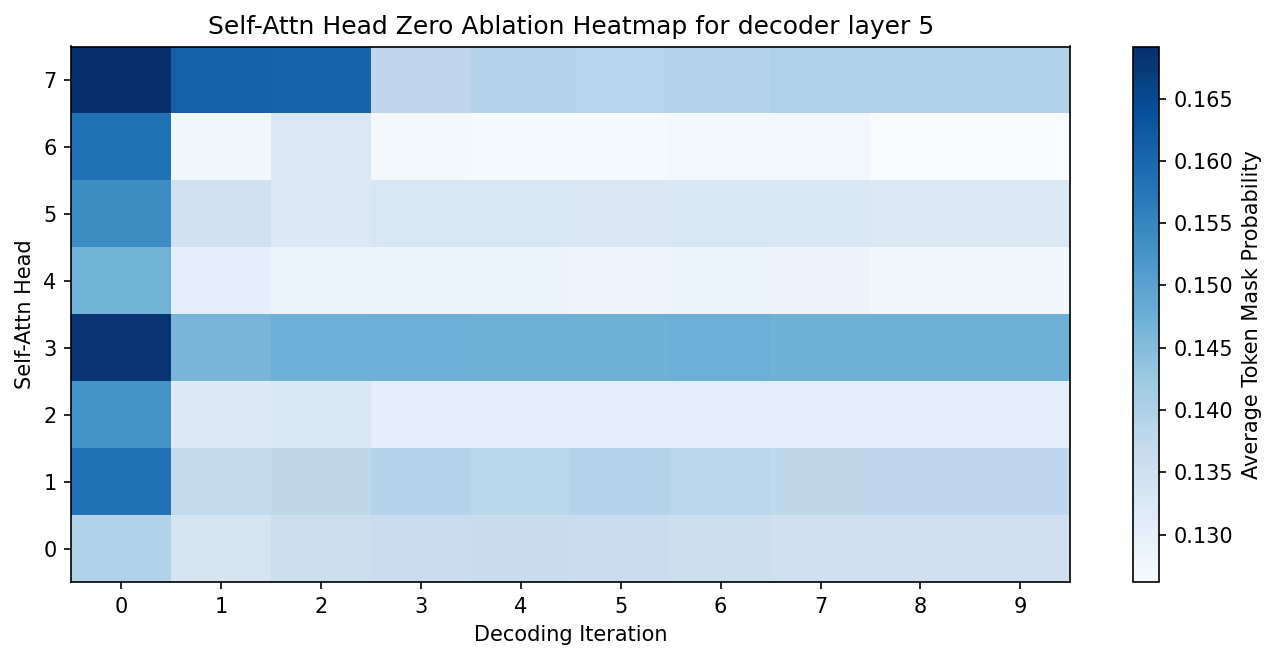

In [43]:
plot_self_attn_head_zero_ablation_heatmap(self_attn_head_zero_sweep_result, cmap="Blues")


## Cross-attn head zero ablation


In [44]:
cross_attn_head_zero_layer_index = cross_attn_layer_index

print("cross-attn head zero layer index:", cross_attn_head_zero_layer_index)
print("target sentence for head zero ablation:", target_sentence)


cross-attn head zero layer index: 5
target sentence for head zero ablation: The bank was open beside the market .


In [45]:
cross_attn_head_zero_sweep_result = decoder_cross_attn_head_zero_ablation_sweep(
    target_sentence=target_sentence,
    context=context,
    layer_index=cross_attn_head_zero_layer_index,
    decoding_iterations=iter_nums,
)


In [46]:
print("cross-attn head zero ablation results:")
for head_result in cross_attn_head_zero_sweep_result["head_results"]:
    print(
        f"head {head_result['head_index']}: overall avg mask prob = {head_result['overall_average_mask_prob']}"
    )
    print("  avg mask probs by iteration:", head_result["average_token_mask_probs_by_iteration"])
    print("  decoded text:", head_result["decoded_text"])


cross-attn head zero ablation results:
head 0: overall avg mask prob = 0.120983
  avg mask probs by iteration: [0.165645, 0.117701, 0.119631, 0.11563, 0.115363, 0.115667, 0.115446, 0.115091, 0.114828, 0.114828]
  decoded text: Die Bank war neben dem Markt offen .
head 1: overall avg mask prob = 0.132546
  avg mask probs by iteration: [0.150515, 0.132073, 0.131168, 0.130599, 0.130336, 0.130666, 0.130337, 0.13004, 0.129865, 0.129865]
  decoded text: Die Bank war neben dem Markt offen .
head 2: overall avg mask prob = 0.130183
  avg mask probs by iteration: [0.150292, 0.134289, 0.124377, 0.127599, 0.127711, 0.127279, 0.127139, 0.127222, 0.12796, 0.12796]
  decoded text: Die Bank war neben dem Markt geöffnet .
head 3: overall avg mask prob = 0.154186
  avg mask probs by iteration: [0.167, 0.153902, 0.152288, 0.152697, 0.152663, 0.152327, 0.152742, 0.153208, 0.152518, 0.152518]
  decoded text: Die Bank war neben dem Markt geöffnet .
head 4: overall avg mask prob = 0.144379
  avg mask probs 

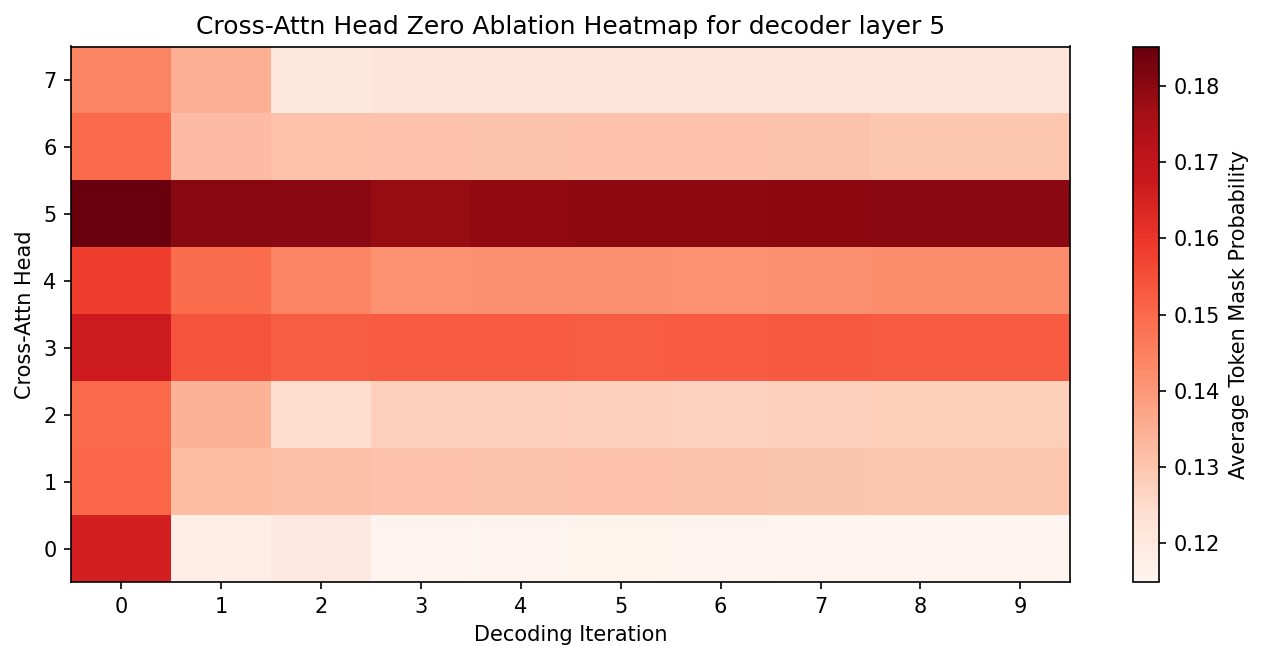

In [47]:
plot_cross_attn_head_zero_ablation_heatmap(cross_attn_head_zero_sweep_result, cmap="Reds")
